<h1 style='font-size:3rem;color:blue;text-align:center; '>Customer Churn Prediction</h1>

<h1 style="text-align:center; font-weight:bold;">Telecom Customer Churn Prediction</h1>

![](1_WZdoYPpmiIk1AcPQ1YHWug.webp)

## 1. Introduction

Customer churn refers to the loss of customers who stop using a company’s products or services. 
The goal of this project is to build a machine learning model that can predict whether a customer 
is likely to churn based on their historical data. 
This helps businesses take proactive actions to retain customers.

### Problem Statement


Identify customers who are likely to churn using demographic, account, and usage information. 
By predicting churn, companies can implement targeted retention strategies and reduce revenue loss.


## 2. Importing essential libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [237]:
import os
print(os.listdir())

import warnings
warnings.filterwarnings('ignore')

['.ipynb_checkpoints', '1_WZdoYPpmiIk1AcPQ1YHWug.webp', 'Customer churn prediction.ipynb', 'customer_churn_model.pkl', 'Customer_Churn_Prediction_using_ML.ipynb', 'Decision tree exercise.ipynb', 'encoders.pkl', 'K-fold cross validation.ipynb', 'Telecom Customer Churn Prediction .ipynb', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


## 3. Load Dataset

We use a customer churn dataset containing details such as customer demographics, 
account information, services subscribed, and churn status.

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')


In [4]:
type(df)

pandas.core.frame.DataFrame

### Understanding the dataset

In [5]:
df.shape

(7043, 21)

In [6]:
pd.set_option("display.max_columns", None) 

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
43,4671-VJLCL,Female,0,No,No,63,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,Yes,Credit card (automatic),79.85,4861.45,No
6916,7242-EDTYC,Male,0,No,Yes,44,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.55,819.95,No
3954,7225-CBZPL,Male,1,Yes,No,17,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.80,1563.9,No
677,0822-GAVAP,Female,0,No,No,2,No,No phone service,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,34.70,62.25,Yes
1316,9788-YTFGE,Male,0,No,No,7,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.95,147.5,No


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# we have no missing values

<h1 style='font-size:1rem;color:red;'> Note: TotalCharges column mentioned as object but it is a numarical type 

In [12]:
# dropping customer ID column

df = df.drop(columns = ['customerID'])

In [13]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [14]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [15]:
# Printing the unique values in each columns

for col in df.columns:
    print(col,df[col].unique())

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges ['29.85' '1889

In [16]:
# Finding null values in the columns

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
# finding the null values in Total charges column

df[df['TotalCharges']==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [18]:
df['TotalCharges'] = df['TotalCharges'].replace({" ": 0.0})

In [19]:
len(df[df['TotalCharges']==" "])

0

In [20]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


##### TotalCharges column has converted into float datatype

## 4. Exploratory Data Analysis (EDA)

We explore the dataset to understand its structure, missing values, 
feature distributions, and relationships between variables and churn.

### Analysing the target variable:

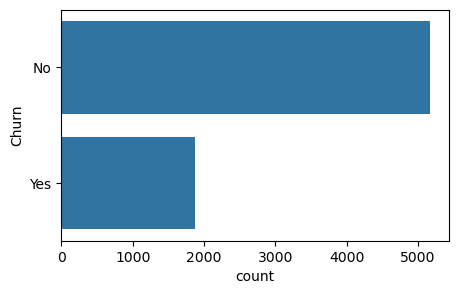

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [22]:
# Checking the Target column - 'Churn'
plt.figure(figsize=(5,3))
sns.countplot(df['Churn'])
plt.show()

churn = df['Churn'].value_counts()
print(churn)

In [23]:
total = len(df['Churn'])

# Active (No churn)
active = (df['Churn'] == 'No').sum()

# Churned (Yes churn)
churned = (df['Churn'] == 'Yes').sum()

# Percentages
print("Percentage of customers with active services: " + str(round((active / total) * 100, 2)))
print("Percentage of churn customers: " + str(round((churned / total) * 100, 2)))  

Percentage of customers with active services: 73.46
Percentage of churn customers: 26.54


The plot above shows the distribution of the target variable **Churn**.  
Out of the total customers:

- **73.46%** (5174 customers) did not churn and continue to use the service.  
- **26.54%** (1869 customers) have churned.  

This indicates that the dataset is **imbalanced**, with a majority of customers falling in the "No Churn" category.  
Such imbalance is common in churn datasets and should be addressed during the modeling stage using techniques like **resampling (SMOTE)**.  

## Numerical features Analysis

In this section, we compare the distribution of numerical features such as **Tenure**, **MonthlyCharges**, and **TotalCharges** against the target variable (Churn).  

In [24]:
X = df.drop('Churn', axis=1)   # Features (independent variables)
y = df['Churn']               # Target (dependent variable)


In [25]:

def barplot(column_name):
    plt.figure(figsize=(5,3))
    sns.barplot(x="Churn", y=column_name, data=df)
    plt.title(f"Bar plot of {column_name} vs churn")
    plt.ylabel(column_name)
    plt.xlabel("Churn")
    plt.show()


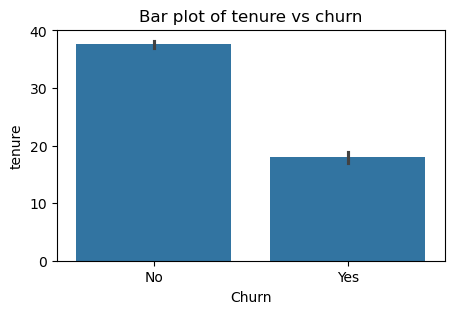

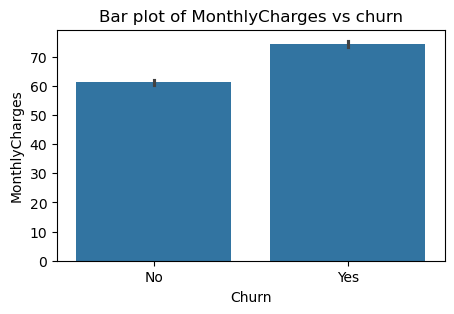

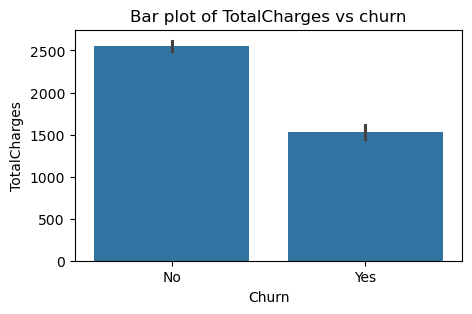

In [26]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    barplot(col)

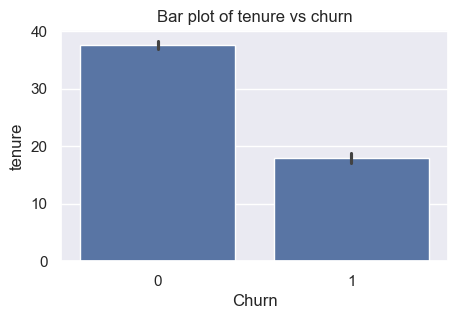

In [217]:
barplot('tenure')

Customers with a **shorter tenure** show a higher churn rate. This indicates that new customers are more likely to leave the service compared to long-term customers. 

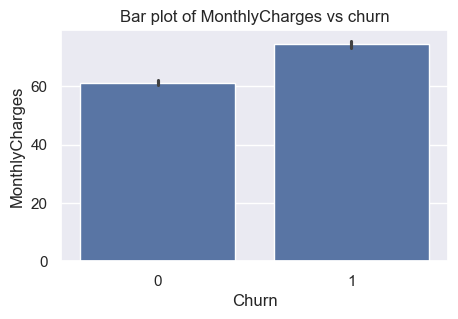

In [219]:
barplot('MonthlyCharges')

Customers with **higher monthly charges** tend to churn more often. This suggests that price sensitivity could be an important factor behind churn.

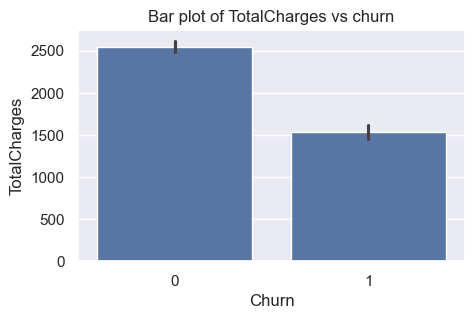

In [220]:
barplot('TotalCharges')

Customers with **lower total charges** are more likely to churn. Since total charges depend on tenure and monthly charges, this aligns with the fact that newer customers (with fewer total charges accumulated) are more likely to leave.  

## Correlation Analysis – Numerical Features

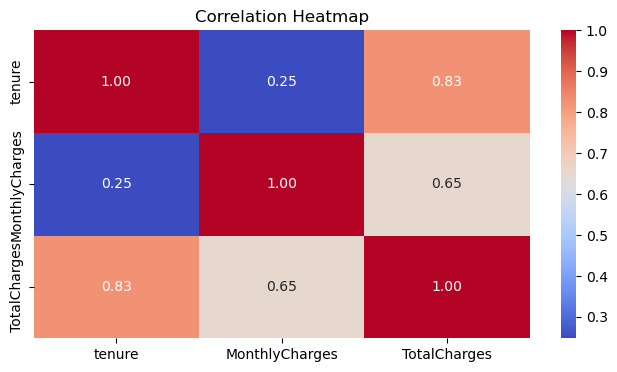

In [27]:
# correlation matix - heatmap
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

## Categorical features Analysis

We analyze categorical features to understand the distribution of customer characteristics.

In [28]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [29]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod','Churn']

### Count plot for categorical colums

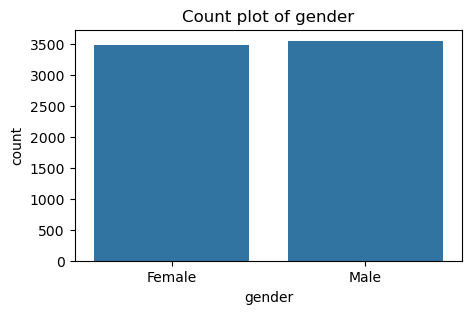

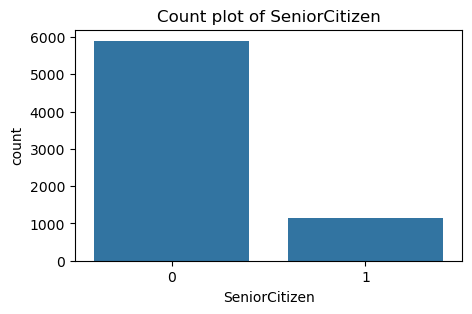

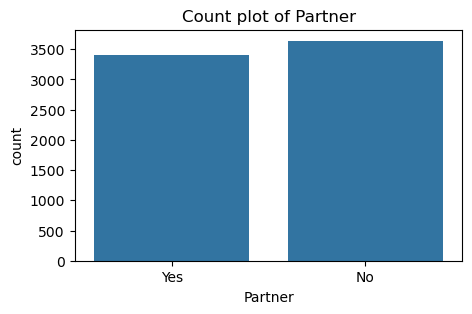

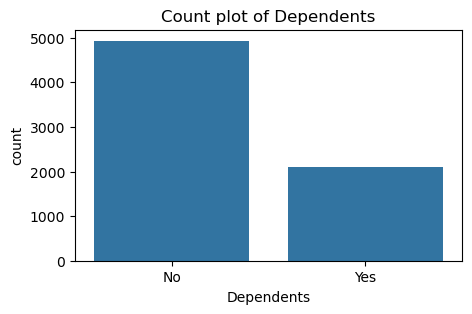

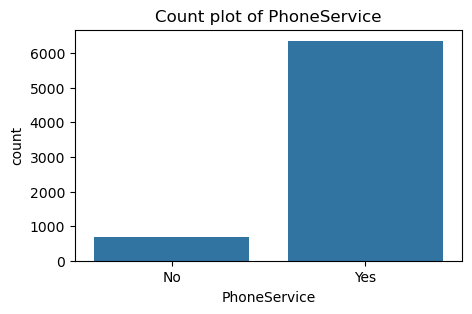

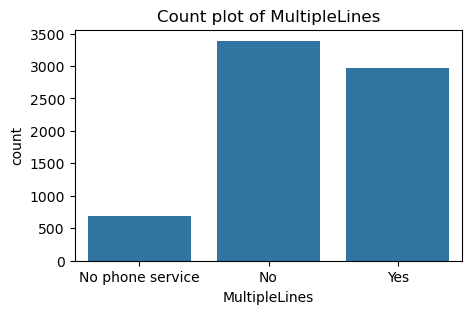

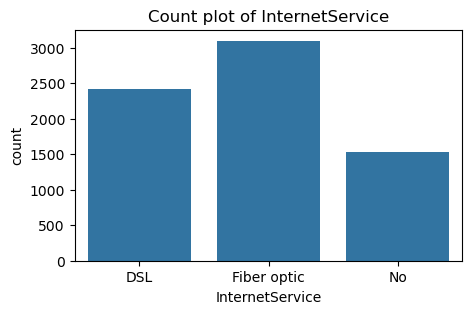

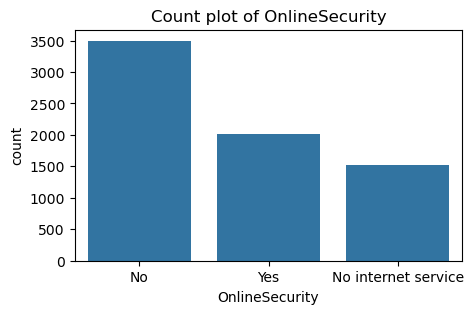

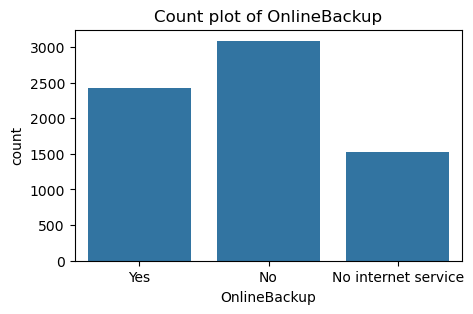

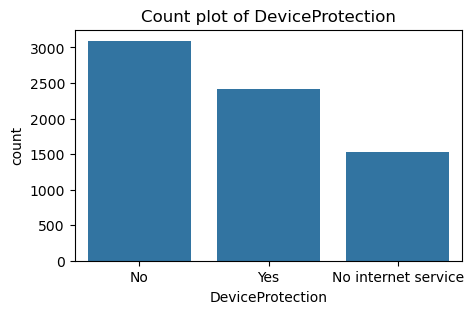

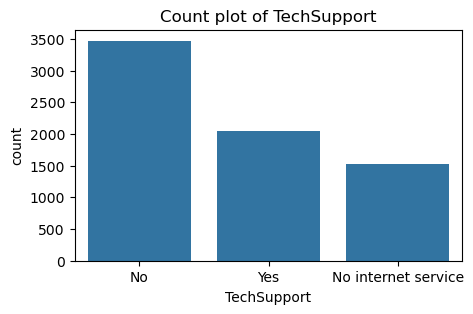

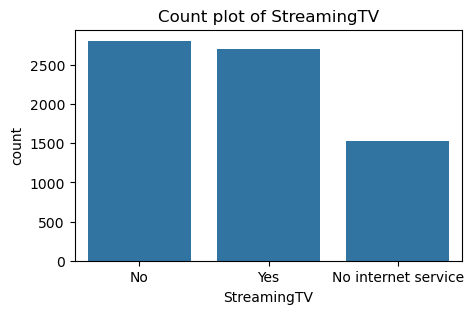

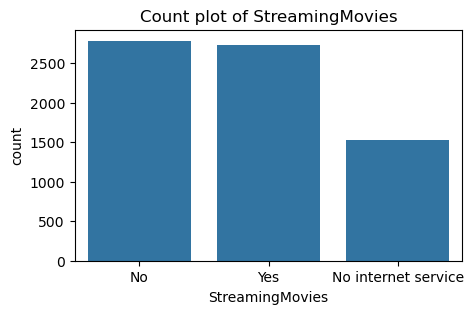

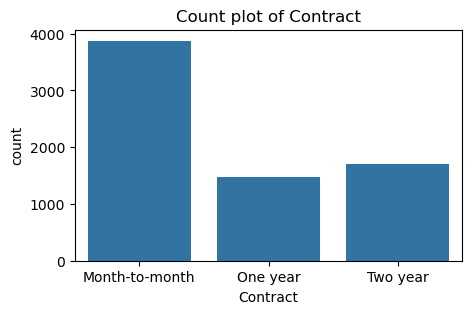

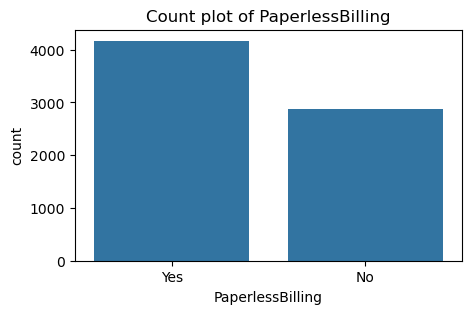

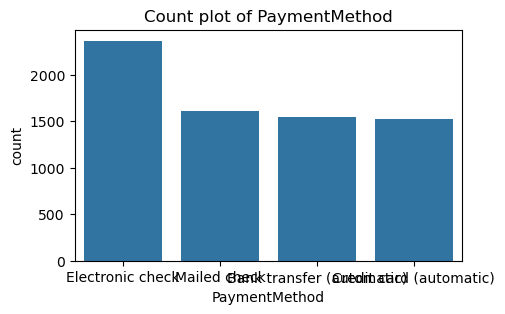

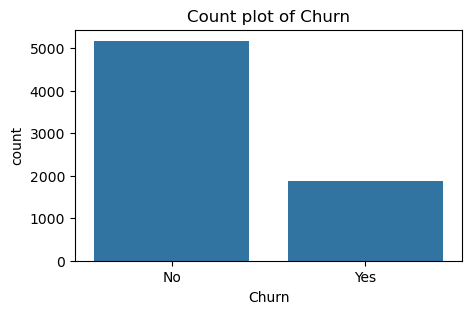

In [30]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f'Count plot of {col}')
    plt.show()

- **Gender** distribution is almost equal between male and female customers, which means gender is balanced in the dataset.  
- **SeniorCitizen** may show fewer elderly customers compared to younger ones.  
- **Contract type** and **Payment method** are expected to have varied distributions, which could significantly influence churn.  

These initial visualizations give us a baseline understanding of categorical features before comparing them directly with churn.

## Numerical Features Analysis

#### Plotting a histogram chart

To understand the spread of numerical variables, we plot histograms with **mean** and **median** lines:


In [33]:
def plot_histogram(df, column_name):
    # Plotting a histogram chart
    plt.figure(figsize=(5,3))
    sns.histplot(df[column_name],kde=True,color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {column_name}")

    # Calculating mean & median values
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    # Adding vertical lines for mean and median
    plt.axvline(col_mean, color='red', linestyle='--',label='Mean')
    plt.axvline(col_median, color='green', linestyle='-',label='Median')

    plt.legend()
    plt.show()
    

- The **histogram** shows the frequency distribution of values.  
- The **red dashed line** represents the mean, while the **green dashed line** represents the median.  

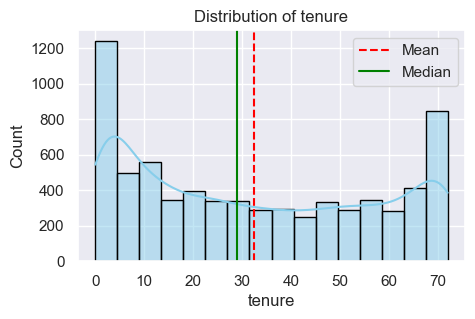

In [228]:
plot_histogram(df, 'tenure')

For the tenure variable, the histogram shows that many customers have **shorter tenures**, with fewer customers staying for very long periods.  
The difference between mean and median indicates some skewness in the distribution. 

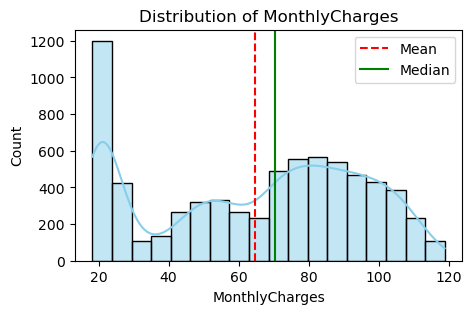

In [35]:
plot_histogram(df,'MonthlyCharges')

Customers are evenly spread across different monthly charges.

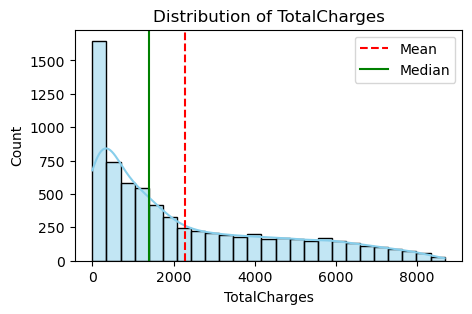

In [36]:
plot_histogram(df, 'TotalCharges')

This is a right-skewed distribution. 

In [37]:
print(df['TotalCharges'].median())
print(df['TotalCharges'].mean())

1394.55
2279.7343035638223


### Box plot for Numerical features to identify outliers

In [230]:
def box_plot(df,column_name):
    plt.figure(figsize=(5,4))
    sns.boxplot(df[column_name])
    plt.title(f'Box plot of {column_name}')
    plt.ylabel(column_name)

    plt.show()
    

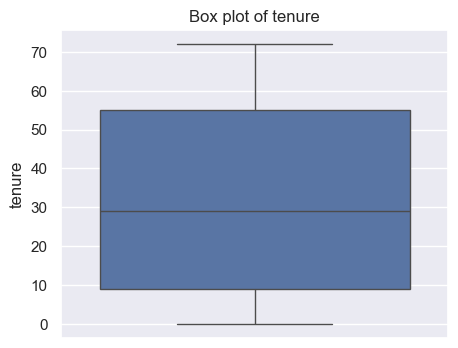

In [231]:
box_plot(df,'tenure')

Tenure is evenly spread, and no extreme outliers are present. Customers range from very new to long-term users.

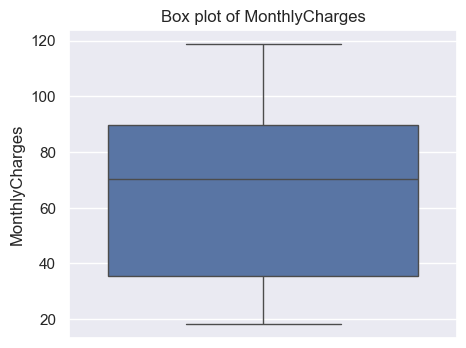

In [235]:
box_plot(df,'MonthlyCharges')

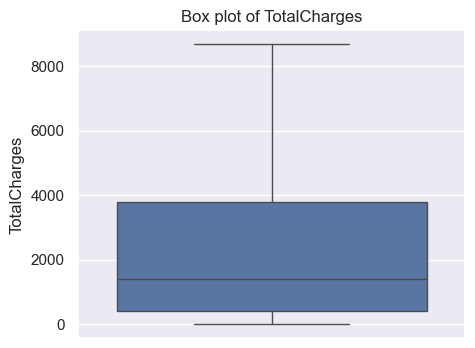

In [233]:
box_plot(df,'TotalCharges')

#### The box plot shows that there are no outliers in the dataset

## 5. Data Preprocessing

### Converting Binary Yes/No Columns → 0/1¶

In [44]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

In [45]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [46]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [47]:
# Identifying columns with object data type
binary_columns= df.select_dtypes(include='object').columns

print(binary_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


#### The pickle file was loaded to restore the saved Python object 

In [48]:
import pickle
from sklearn.preprocessing import LabelEncoder

# Initializing a dict to save encoders
encoder = {}

# Apply label encoding & store encoderds
for col in binary_columns:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col].astype(str))
    encoder[col] = label_encoder

# save encoders in pickle file
with open('encoders.pkl','wb') as f:
    pickle.dump(encoder, f)

In [49]:
encoder

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [50]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


### Training and Test data split

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
# splitting the features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [53]:
# split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
print(y_train.shape)

(5634,)


In [79]:
print(y_test.shape)

(1409,)


In [55]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


The dataset was split into training (5634) and testing (1409) sets. The target variable “Churn” is imbalanced, with far fewer churned customers than non-churned. 

To handle this imbalance, SMOTE will be applied next to oversample the minority class before training the model.

### Synthetic Minority Oversampling Technique - SMOTE

In [65]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

In [66]:

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [67]:
print(y_train_smote.shape)

(8276,)


In [68]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


Using SMOTE here because the churn dataset has a 73:27 imbalance. SMOTE will balance it and help the model detect churners better.

## 6. Model Evaluation

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

In [196]:
print(y_test.value_counts())

Churn
0    1036
1     373
Name: count, dtype: int64


### 1. Logistic Regression

In [70]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

In [71]:
log_reg.fit(X_train_smote,y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [117]:
y_pred = log_reg.predict(X_test)

print("Accuracy:",  round(accuracy_score(y_test, y_pred)*100,2))

Accuracy: 76.51


In [118]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.54      0.79      0.64       373

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



In [154]:
scores = cross_val_score(log_reg,X_train_smote,y_train_smote,cv=10,scoring="accuracy")
lr_score = round(np.mean(scores)*100,2)
print(f"Logestic Regression cross-validation accuracy:{lr_score}%")

Logestic Regression cross-validation accuracy:79.76%


#### Logistic Regression Accuracy is 79.76%

### 2. Decision Tree

In [92]:
dt = DecisionTreeClassifier(random_state=42)

In [93]:
dt.fit(X_train_smote,y_train_smote)

DecisionTreeClassifier(random_state=42)

In [119]:
y_pred = dt.predict(X_test)

In [120]:
print("Accuracy:",  round(accuracy_score(y_test, y_pred)*100,2))

Accuracy: 72.11


In [121]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.78      0.80      1036
           1       0.48      0.55      0.51       373

    accuracy                           0.72      1409
   macro avg       0.65      0.67      0.66      1409
weighted avg       0.74      0.72      0.73      1409



In [155]:
scores =  cross_val_score(dt,X_train_smote,y_train_smote,cv=10,scoring="accuracy")
dt_score = round(np.mean(scores)*100,2)
print(f"Decision tree cross-validation accuracy:{dt_score}%")

Decision tree cross-validation accuracy:78.52%


#### Decision tree accuracy is 78.52%

### Random Forest

In [127]:
rf = RandomForestClassifier( random_state=42)

In [128]:
rf.fit(X_train_smote, y_train_smote)

y_pred = rf.predict(X_test)

In [129]:
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100,2))

Accuracy: 77.71


In [130]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [156]:
scores = cross_val_score(rf,X_train_smote,y_train_smote,cv=10,scoring="accuracy")
rf_score = round(np.mean(scores)*100,2)
print(f"Decision tree cross-validation accuracy:{rf_score}%")

Decision tree cross-validation accuracy:84.84%


#### Random forest accuracy is 84.84%

### XGBoost

In [124]:
import xgboost as xgb

xgb = xgb.XGBClassifier(objective="binary:logistic", random_state=42)

xgb.fit(X_train_smote,y_train_smote)

y_pred = xgb.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100,2))

Accuracy: 78.21


In [115]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [158]:
scores = cross_val_score(xgb,X_train_smote,y_train_smote,cv=10,scoring="accuracy")
xgb_score = round(np.mean(scores)*100,2)

print(f"Cross-validation accuracy:{xgb_score}%")

Cross-validation accuracy:83.91%


##### The accuracy score achieved using XGBoost is: 83.91%

## 7. Results & Comparison

In [160]:
scores = [lr_score, dt_score, rf_score, xgb_score]
algorithms = ["Logistic Regression","Decision Tree","Random Forest","XGBoost"]

In [161]:
for i in range(len(algorithms)):
     print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")

The accuracy score achieved using Logistic Regression is: 83.91 %
The accuracy score achieved using Decision Tree is: 78.52 %
The accuracy score achieved using Random Forest is: 84.84 %
The accuracy score achieved using XGBoost is: 83.91 %


#### Random Forest and XGBoost gives the highest accuracy compared to other models with default parameters

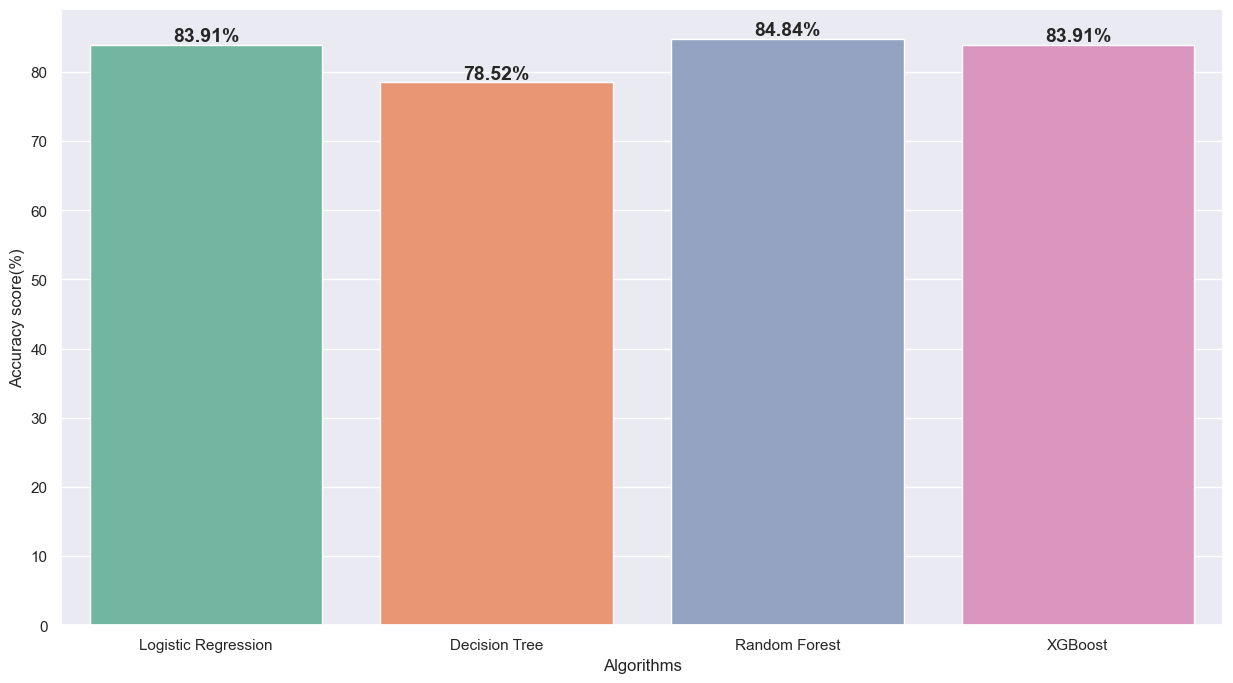

In [195]:
sns.set(rc={'figure.figsize':(15,8)})
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score(%)")

sns.barplot(x=algorithms,y=scores,palette="Set2")

# Add text labels on top of bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontsize=14, fontweight='bold')


plt.show()

### Random forest has good result as compare to other algorithms


In [199]:
# Save trained model as a pickle file

with open("customer_churn_model.pkl","wb") as f:
    pickle.dump(rf, f)

In [200]:
# Load the saved model and the encoders


In [202]:
data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

In [204]:
df_input = pd.DataFrame([data])

In [205]:
with open('encoders.pkl','rb') as f:
    encoders = pickle.load(f)

In [206]:
df_input.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85


In [207]:
for column, encoder in encoders.items():
    df_input[column] = encoder.transform(df_input[column])
    

In [208]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [213]:
# To make a predictions

prediction = rf.predict(df_input)

if prediction==1:
    print("Prediction: Churn")
else:
    print('Prediction:No Churn')

Prediction:No Churn


## 10. Conclusion

Customers with month-to-month contracts and high service charges are more likely to churn. Long-term contracts reduce churn risk.he best-performing model was **Random Forest**, which can be used to identify at-risk customers 